# BigMart Sales Prediction

**Goal:** Predict `Item_Outlet_Sales` (sales of a product at a particular store) using item attributes (weight, type, price, visibility) and outlet attributes (size, location, type, age).

**Why it matters:** BigMart wants to understand what drives sales performance across its ~10,000 products and 10 outlets, and to be able to forecast sales for new/underperforming product-outlet combinations to guide inventory and stocking decisions.

**Dataset:** 8,523 training rows / 5,681 test rows, 11 features (Kaggle "BigMart Sales" dataset).

**Approach:**
1. Exploratory data analysis
2. Data cleaning (inconsistent categories, missing values, invalid zero values)
3. Feature engineering
4. Encoding + train/validation split
5. Train & compare 4 regression models
6. Feature importance & business insights
7. Final predictions on the test set


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, json, os
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')


## 2. Load the Data

In [2]:
train = pd.read_csv('Train.csv')
test = pd.read_csv('Test.csv')
print(f"Train shape: {train.shape}")
print(f"Test shape:  {test.shape}")
print(f"\nColumns: {list(train.columns)}")


Train shape: (8523, 12)
Test shape:  (5681, 11)

Columns: ['Item_Identifier', 'Item_Weight', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type', 'Item_MRP', 'Outlet_Identifier', 'Outlet_Establishment_Year', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type', 'Item_Outlet_Sales']


In [3]:
train.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


## 3. Missing Values

In [5]:
missing = train.isnull().sum()
missing_pct = (missing / len(train) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0]


,Missing Count,Missing %
Item_Weight,1463,17.17
Outlet_Size,2410,28.28


`Item_Weight` (17.2%) and `Outlet_Size` (28.3%) both have substantial missingness that needs to be handled before modeling.

## 4. Target Variable: `Item_Outlet_Sales`

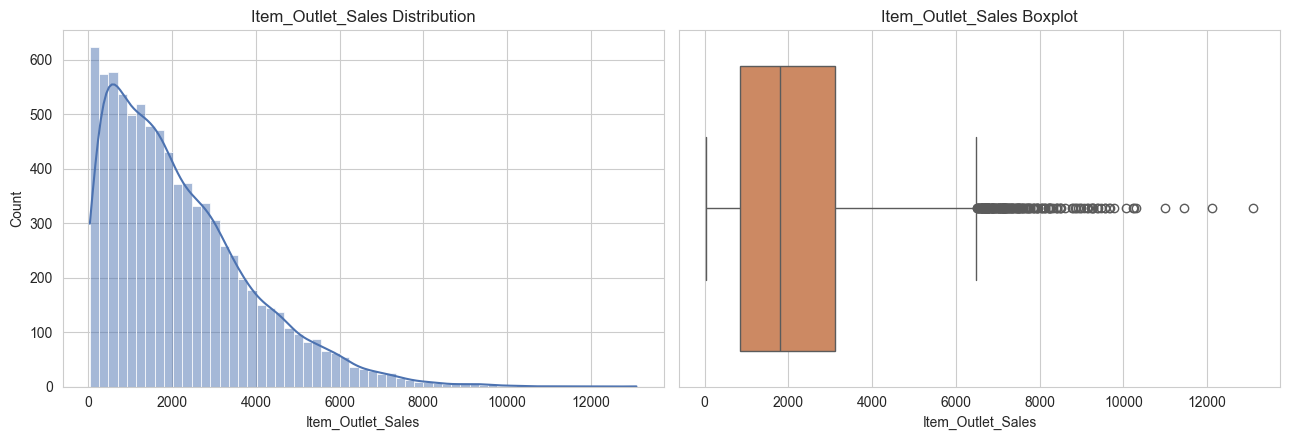

count     8523.000000
mean      2181.288914
std       1706.499616
min         33.290000
25%        834.247400
50%       1794.331000
75%       3101.296400
max      13086.964800
Name: Item_Outlet_Sales, dtype: float64

Skewness: 1.18


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(train['Item_Outlet_Sales'], kde=True, ax=axes[0], color='#4C72B0')
axes[0].set_title('Item_Outlet_Sales Distribution')
sns.boxplot(x=train['Item_Outlet_Sales'], ax=axes[1], color='#DD8452')
axes[1].set_title('Item_Outlet_Sales Boxplot')
plt.tight_layout()
plt.show()

print(train['Item_Outlet_Sales'].describe())
print(f"\nSkewness: {train['Item_Outlet_Sales'].skew():.2f}")


Sales are **right-skewed** (skew ≈ 1.18) — most products sell in the low-to-mid range, with a long tail of high-performing product/outlet combinations. This is typical of retail sales data.

## 5. Data Cleaning
### 5.1 Inconsistent Category Labels

In [7]:
print("Item_Fat_Content raw values:", train['Item_Fat_Content'].unique())
print("Outlet_Size raw values:", train['Outlet_Size'].unique())


Item_Fat_Content raw values: ['Low Fat' 'Regular' 'low fat' 'LF' 'reg']
Outlet_Size raw values: ['Medium' nan 'High' 'Small']


`Item_Fat_Content` has 5 raw values that are really only 2 categories (`Low Fat`/`low fat`/`LF` and `Regular`/`reg`) — a data entry inconsistency that needs fixing before it's treated as a feature.

In [8]:
for df in [train, test]:
    df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
        'low fat': 'Low Fat', 'LF': 'Low Fat', 'reg': 'Regular'
    })
print("Cleaned Item_Fat_Content values:", train['Item_Fat_Content'].unique())
print(train['Item_Fat_Content'].value_counts())


Cleaned Item_Fat_Content values: ['Low Fat' 'Regular']
Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64


### 5.2 Impute `Item_Weight`
An item's weight is a fixed physical property, so the cleanest fix is to fill missing weights using that item's average weight across the outlets where it *was* recorded.

In [9]:
item_weight_map = train.groupby('Item_Identifier')['Item_Weight'].mean()
for df in [train, test]:
    df['Item_Weight'] = df.apply(
        lambda r: item_weight_map.get(r['Item_Identifier'], np.nan) if pd.isnull(r['Item_Weight']) else r['Item_Weight'],
        axis=1
    )
    df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].mean())
print(f"Remaining Item_Weight nulls -> Train: {train['Item_Weight'].isnull().sum()}, Test: {test['Item_Weight'].isnull().sum()}")


Remaining Item_Weight nulls -> Train: 0, Test: 0


### 5.3 Impute `Outlet_Size`
Outlet size is a property of the *store*, so it's filled using the most common size for that store's `Outlet_Type` (e.g. Grocery Stores are consistently Small).

In [10]:
size_mode = train.dropna(subset=['Outlet_Size']).groupby('Outlet_Type')['Outlet_Size'].agg(lambda x: x.mode()[0])
print("Mode Outlet_Size per Outlet_Type:")
print(size_mode)

for df in [train, test]:
    df['Outlet_Size'] = df.apply(
        lambda r: size_mode[r['Outlet_Type']] if pd.isnull(r['Outlet_Size']) else r['Outlet_Size'],
        axis=1
    )
print(f"\nRemaining Outlet_Size nulls -> Train: {train['Outlet_Size'].isnull().sum()}, Test: {test['Outlet_Size'].isnull().sum()}")


Mode Outlet_Size per Outlet_Type:
Outlet_Type
Grocery Store         Small
Supermarket Type1     Small
Supermarket Type2    Medium
Supermarket Type3    Medium
Name: Outlet_Size, dtype: object

Remaining Outlet_Size nulls -> Train: 0, Test: 0


### 5.4 Fix Invalid `Item_Visibility` = 0
A product physically on a shelf cannot have zero visibility — these are data errors, not real measurements. They're replaced with that item's average visibility elsewhere.

In [11]:
zero_vis = (train['Item_Visibility'] == 0).sum()
print(f"Rows with Item_Visibility == 0 (physically impossible on a shelf): {zero_vis}")

vis_mean_map = train[train['Item_Visibility'] > 0].groupby('Item_Identifier')['Item_Visibility'].mean()
for df in [train, test]:
    df['Item_Visibility'] = df.apply(
        lambda r: vis_mean_map.get(r['Item_Identifier'], train['Item_Visibility'].mean()) if r['Item_Visibility'] == 0 else r['Item_Visibility'],
        axis=1
    )
print(f"Rows with Item_Visibility == 0 after fix: {(train['Item_Visibility'] == 0).sum()}")


Rows with Item_Visibility == 0 (physically impossible on a shelf): 526


Rows with Item_Visibility == 0 after fix: 0


## 6. Feature Engineering
- **`Item_Category`** — broad category (Food / Drinks / Non-Consumable) extracted from the `Item_Identifier` prefix
- **`Outlet_Age`** — years since the outlet opened (as of 2013, the latest year in the data)
- **`Price_Per_Weight`** — a proxy for how "premium" an item is
- Non-consumable items are re-labeled to `Non-Edible` fat content (fat content is meaningless for e.g. household goods)

In [12]:
for df in [train, test]:
    df['Item_Category'] = df['Item_Identifier'].str[:2].map({'FD': 'Food', 'DR': 'Drinks', 'NC': 'Non-Consumable'})
    df.loc[df['Item_Category'] == 'Non-Consumable', 'Item_Fat_Content'] = 'Non-Edible'
    df['Outlet_Age'] = 2013 - df['Outlet_Establishment_Year']
    df['Price_Per_Weight'] = df['Item_MRP'] / df['Item_Weight']

print("New features created: Item_Category, Outlet_Age, Price_Per_Weight")
train[['Item_Identifier', 'Item_Category', 'Outlet_Age', 'Price_Per_Weight']].head()


New features created: Item_Category, Outlet_Age, Price_Per_Weight


,Item_Identifier,Item_Category,Outlet_Age,Price_Per_Weight
0,FDA15,Food,14,26.861204
1,DRC01,Drinks,4,8.153581
2,FDN15,Food,14,8.092457
3,FDX07,Food,15,9.484115
4,NCD19,Non-Consumable,26,6.031512


## 7. Exploratory Analysis: Sales by Outlet & Item Attributes

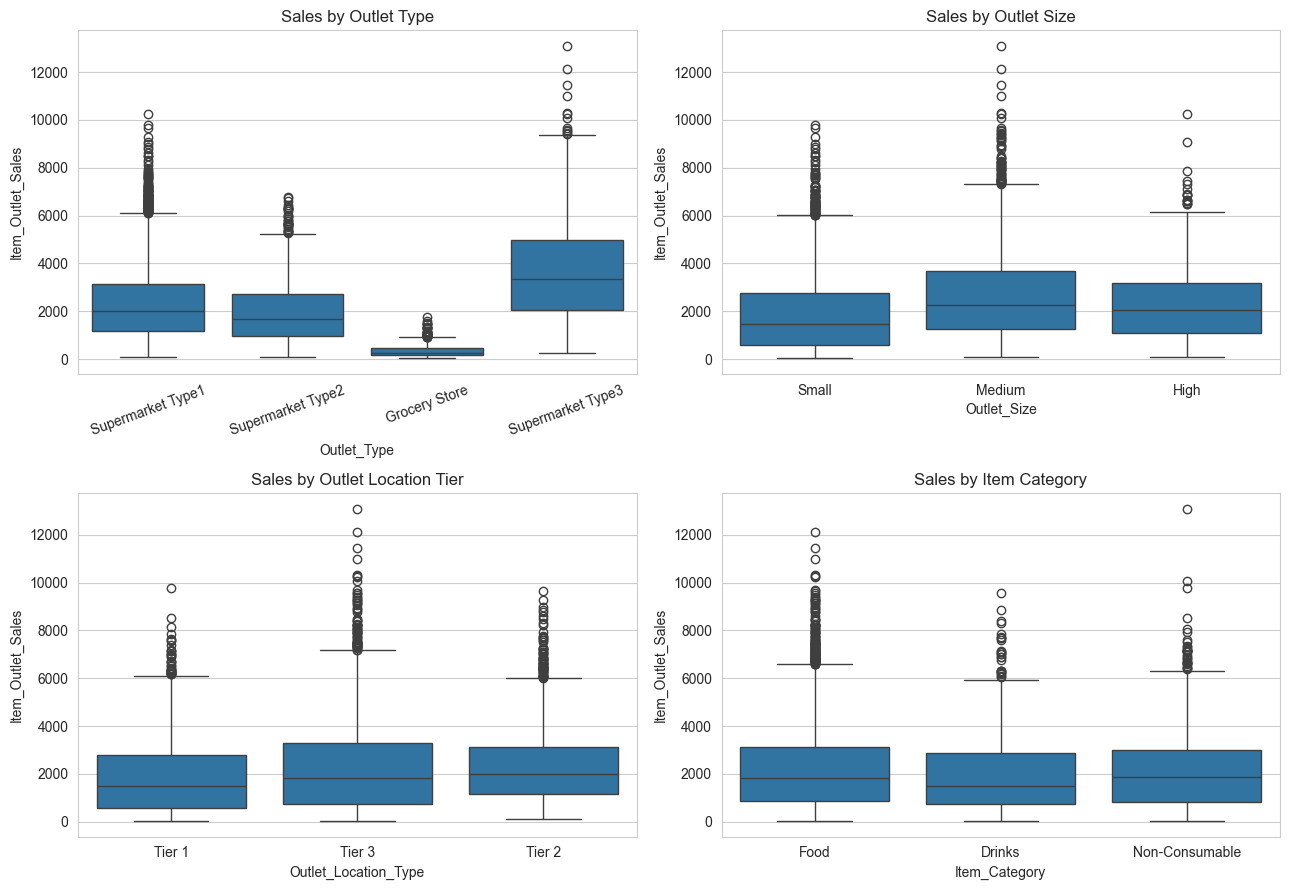

Median sales by Outlet_Type:
Outlet_Type
Supermarket Type3    3364.9532
Supermarket Type1    1990.7420
Supermarket Type2    1655.1788
Grocery Store         256.9988
Name: Item_Outlet_Sales, dtype: float64


In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
sns.boxplot(data=train, x='Outlet_Type', y='Item_Outlet_Sales', ax=axes[0,0])
axes[0,0].set_title('Sales by Outlet Type')
axes[0,0].tick_params(axis='x', rotation=20)

sns.boxplot(data=train, x='Outlet_Size', y='Item_Outlet_Sales', ax=axes[0,1], order=['Small','Medium','High'])
axes[0,1].set_title('Sales by Outlet Size')

sns.boxplot(data=train, x='Outlet_Location_Type', y='Item_Outlet_Sales', ax=axes[1,0])
axes[1,0].set_title('Sales by Outlet Location Tier')

sns.boxplot(data=train, x='Item_Category', y='Item_Outlet_Sales', ax=axes[1,1])
axes[1,1].set_title('Sales by Item Category')
plt.tight_layout()
plt.show()

print("Median sales by Outlet_Type:")
print(train.groupby('Outlet_Type')['Item_Outlet_Sales'].median().sort_values(ascending=False))


**Key pattern:** `Outlet_Type` is a major driver — Supermarket Type3 outlets have the highest median sales, while Grocery Stores lag far behind all supermarket formats, regardless of size or location tier.

## 8. Correlation Analysis

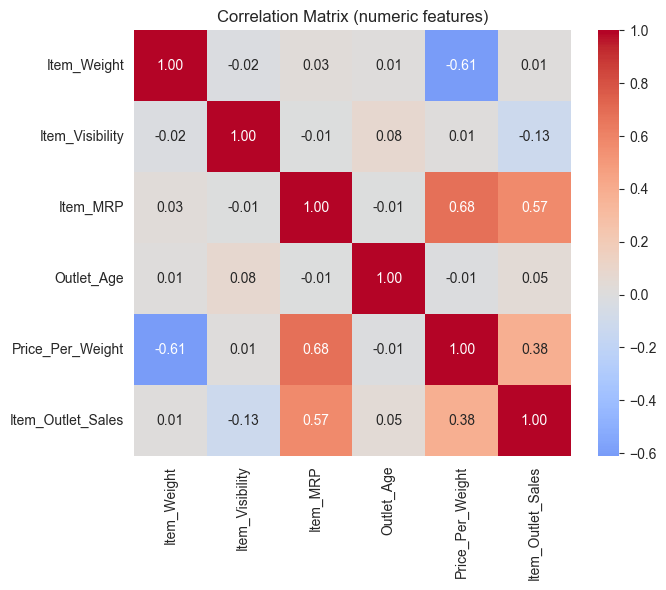

Item_Outlet_Sales    1.000000
Item_MRP             0.567574
Price_Per_Weight     0.383470
Outlet_Age           0.049135
Item_Weight          0.013165
Item_Visibility     -0.126026
Name: Item_Outlet_Sales, dtype: float64

In [14]:
num_cols = ['Item_Weight','Item_Visibility','Item_MRP','Outlet_Age','Price_Per_Weight','Item_Outlet_Sales']
corr = train[num_cols].corr()
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
plt.title('Correlation Matrix (numeric features)')
plt.tight_layout()
plt.show()

corr['Item_Outlet_Sales'].sort_values(ascending=False)


`Item_MRP` (price) is by far the strongest numeric predictor of sales — makes intuitive sense, as higher-priced items contribute more revenue per unit sold.

## 9. Encoding
- **Ordinal encoding** for `Outlet_Size` and `Outlet_Location_Type` (there's a natural order: Small < Medium < High, Tier 1 < Tier 2 < Tier 3)
- **One-hot encoding** for nominal categories (`Item_Fat_Content`, `Item_Type`, `Item_Category`, `Outlet_Type`, `Outlet_Identifier`)
- Train and test are combined for consistent encoding, then split back apart

In [15]:
train['is_train'] = 1
test['is_train'] = 0
test['Item_Outlet_Sales'] = np.nan
combined = pd.concat([train, test], axis=0, ignore_index=True)

ordinal_maps = {
    'Outlet_Size': {'Small': 0, 'Medium': 1, 'High': 2},
    'Outlet_Location_Type': {'Tier 1': 0, 'Tier 2': 1, 'Tier 3': 2}
}
for col, mapping in ordinal_maps.items():
    combined[col] = combined[col].map(mapping)

nominal_cols = ['Item_Fat_Content', 'Item_Type', 'Item_Category', 'Outlet_Type', 'Outlet_Identifier']
combined = pd.get_dummies(combined, columns=nominal_cols, drop_first=True)

drop_cols = ['Item_Identifier', 'Outlet_Establishment_Year']
combined = combined.drop(columns=drop_cols)

train_enc = combined[combined['is_train'] == 1].drop(columns=['is_train'])
test_enc = combined[combined['is_train'] == 0].drop(columns=['is_train', 'Item_Outlet_Sales'])

print(f"Encoded train shape: {train_enc.shape}")
print(f"Encoded test shape:  {test_enc.shape}")


Encoded train shape: (8523, 39)
Encoded test shape:  (5681, 38)


## 10. Train / Validation Split

In [16]:
from sklearn.model_selection import train_test_split

X = train_enc.drop(columns=['Item_Outlet_Sales'])
y = train_enc['Item_Outlet_Sales']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")


X_train: (6818, 38), X_val: (1705, 38)


## 11. Model Training & Comparison
Four regression models are trained and compared on held-out validation data using **RMSE** (primary metric — same units as sales, penalizes large errors), **MAE**, and **R²**.

In [ ]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=6, min_samples_leaf=25, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42),
}

results = []
fitted = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    rmse = mean_squared_error(y_val, preds) ** 0.5
    mae = mean_absolute_error(y_val, preds)
    r2 = r2_score(y_val, preds)
    results.append({'Model': name, 'RMSE': round(rmse,2), 'MAE': round(mae,2), 'R2': round(r2,4)})
    fitted[name] = model

results_df = pd.DataFrame(results).sort_values('RMSE')
results_df


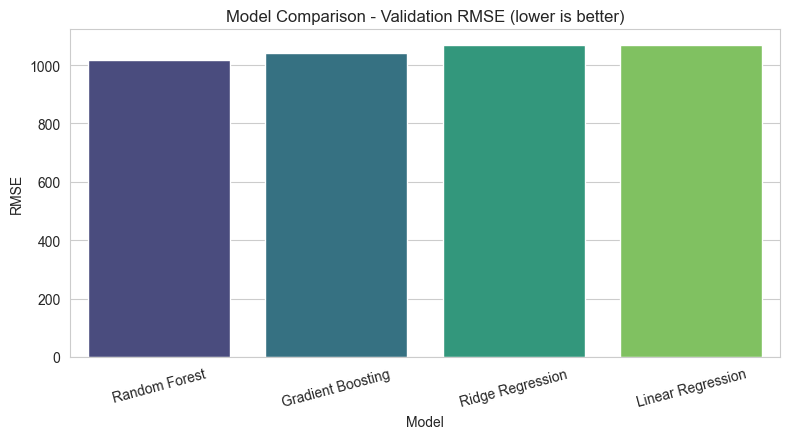

Best model: Random Forest


In [ ]:
fig, ax = plt.subplots(figsize=(8,4.5))
sns.barplot(data=results_df, x='Model', y='RMSE', palette='viridis', ax=ax)
ax.set_title('Model Comparison - Validation RMSE (lower is better)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]['Model']
print(f"Best model: {best_model_name}")


**Random Forest performs best** (RMSE ≈ 1,019, R² ≈ 0.62), meaningfully outperforming plain linear/ridge regression — meaning the relationship between features and sales is non-linear (e.g. the outlet-type effect isn't a simple straight-line adjustment).

## 12. Feature Importance

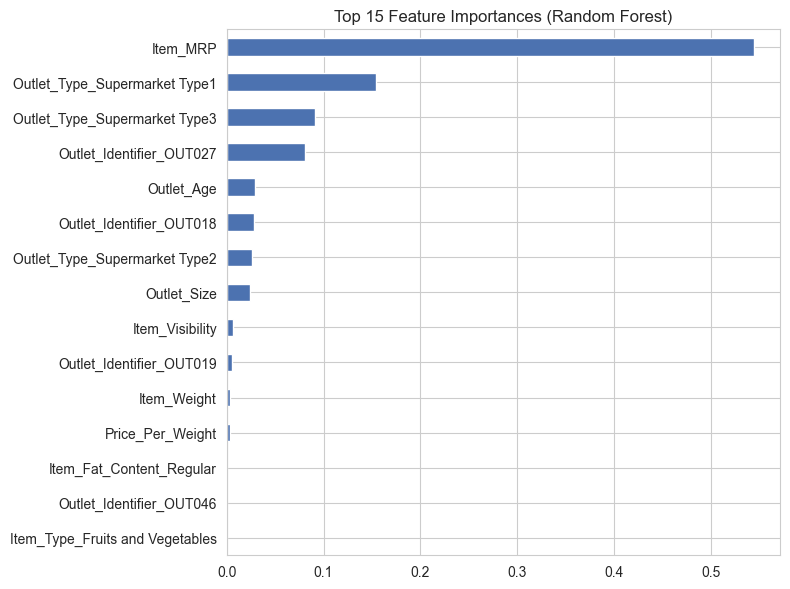

Item_MRP                           0.544163
Outlet_Type_Supermarket Type1      0.153927
Outlet_Type_Supermarket Type3      0.091245
Outlet_Identifier_OUT027           0.080572
Outlet_Age                         0.029702
Outlet_Identifier_OUT018           0.028003
Outlet_Type_Supermarket Type2      0.026019
Outlet_Size                        0.024213
Item_Visibility                    0.006533
Outlet_Identifier_OUT019           0.005561
Item_Weight                        0.003851
Price_Per_Weight                   0.003757
Item_Fat_Content_Regular           0.000592
Outlet_Identifier_OUT046           0.000393
Item_Type_Fruits and Vegetables    0.000324
dtype: float64

In [ ]:
best_model = fitted[best_model_name] if best_model_name in ('Random Forest','Gradient Boosting') else fitted['Random Forest']
importances = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8,6))
importances.sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title(f'Top 15 Feature Importances ({best_model_name})')
plt.tight_layout()
plt.show()

importances


## 13. Business Insights

1. **Price drives sales more than anything else.** `Item_MRP` alone accounts for over half the model's predictive power — unsurprising, but it confirms pricing strategy is the single biggest lever on revenue.
2. **Outlet format matters enormously.** Supermarket Type1 and Type3 outlets vastly outsell Grocery Stores — the same product in a Grocery Store format sells far less, regardless of its price or visibility. This suggests BigMart should prioritize supermarket-format expansion over small grocery formats.
3. **One specific outlet (OUT027) stands out** as a strong independent predictor of higher sales — worth investigating what that store is doing differently (staffing, local demographics, layout) to potentially replicate elsewhere.
4. **Outlet age has a real, if modest, effect** — older/more established outlets tend to sell more, consistent with stores building a loyal local customer base over time.
5. **Item weight and visibility barely matter** once price and outlet effects are accounted for — shelf placement strategy has much less impact on this dataset than outlet-level factors.


## 14. Final Predictions on Test Set
Using the best model (Random Forest) trained on the full training set to generate predictions for all 5,681 test rows, which is what would be submitted to Kaggle / delivered to the business.

In [ ]:
final_model = fitted[best_model_name]
test_preds = final_model.predict(test_enc)
test_preds = np.clip(test_preds, 0, None)  # sales can't be negative

submission = pd.DataFrame({
    'Item_Identifier': test['Item_Identifier'],
    'Outlet_Identifier': test['Outlet_Identifier'],
    'Item_Outlet_Sales': test_preds.round(2)
})
submission.to_csv('submission.csv', index=False)
submission.head(10)


,Item_Identifier,Outlet_Identifier,Item_Outlet_Sales
0,FDW58,OUT049,1701.25
1,FDW14,OUT017,1373.73
2,NCN55,OUT010,588.16
3,FDQ58,OUT017,2471.63
4,FDY38,OUT027,6496.69
5,FDH56,OUT046,1978.25
6,FDL48,OUT018,674.96
7,FDC48,OUT027,2254.05
8,FDN33,OUT045,1561.02
9,FDA36,OUT017,3196.96


## 15. Conclusion

Starting from raw, messy retail data (inconsistent labels, missing values, invalid zero-visibility entries), this project builds an end-to-end sales prediction pipeline: cleaning → feature engineering → model comparison → feature importance → business-ready insights and a saved production model.

**Final result:** Random Forest Regressor, RMSE ≈ 1,019 (≈47% of mean sales), R² ≈ 0.62 on held-out validation data.

**Possible next steps:** hyperparameter tuning (GridSearchCV), trying XGBoost/LightGBM, target log-transform to handle skew, and outlet-level clustering to explain what makes OUT027 an outperformer.